In [6]:
import pandas as pd
import numpy as np

In [2]:
#loading the dataset
train_df = pd.read_csv('../data/Train_data.csv')

In [3]:
#Checking for missing values
missing_values = train_df.isnull().sum()
missing_percent = (missing_values / len(train_df)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})

print("Missing Values Summary:")
print(missing_summary.sort_values(by='Missing Values', ascending=False))

Missing Values Summary:
                    Missing Values  Percentage
Date_of_Occupancy              508    7.094972
Building Dimension             106    1.480447
Geo_Code                       102    1.424581
Garden                           7    0.097765
Customer Id                      0    0.000000
YearOfObservation                0    0.000000
Building_Fenced                  0    0.000000
Building_Painted                 0    0.000000
Residential                      0    0.000000
Insured_Period                   0    0.000000
Building_Type                    0    0.000000
Settlement                       0    0.000000
NumberOfWindows                  0    0.000000
Claim                            0    0.000000


In [4]:
#cheking for duplicates
duplicate_count = train_df.duplicated().sum()
duplicate_count

np.int64(0)

In [7]:
#Checking for numeric and categorical columns
numerical_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['YearOfObservation', 'Insured_Period', 'Residential', 'Building Dimension', 'Building_Type', 'Date_of_Occupancy', 'Claim']
Categorical Features: ['Customer Id', 'Building_Painted', 'Building_Fenced', 'Garden', 'Settlement', 'NumberOfWindows', 'Geo_Code']


Precedently we says that our data were imballanced based on the count of the target variable Claim. In this section we will effectively check it and visualy see it

In [ ]:
target = 'Claim'
if target in train_df.columns:
    class_counts = train_df[target].value_counts()
    class_proportions = train_df[target].value_counts(normalize=True) * 100
print(f"Class Counts:{class_counts}")
print(f"Class Proportions:{class_proportions}")


Class Counts:Claim
0    5526
1    1634
Name: count, dtype: int64
Class Proportions:Claim
0    77.178771
1    22.821229
Name: proportion, dtype: float64


We can see that the class_proportion have a minimum of 22% less than 40% then we can easly say that our data is imbalance

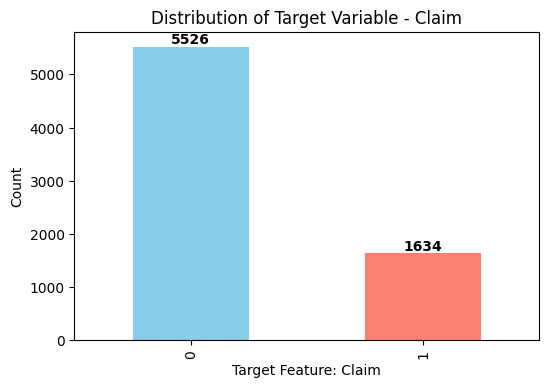

In [10]:
#Visualizing the Target Variable Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Target Variable - Claim')
plt.xlabel('Target Feature: Claim')
plt.ylabel('Count')
for i, v in enumerate(class_counts):
        plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.show()